# Vehicle Insurance Claim Fraud Detection
## End-to-End ML Classification Project

**Dataset:** Car Insurance Fraud Detection (Kaggle)  



In [21]:
import subprocess
import sys
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
for p in ["matplotlib", "seaborn"]:
    try:
        __import__(p)
    except ImportError:
        install(p)
print("Ready.")

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


Ready.


---
## 1. Data Import

### 1.1 Connect to Kaggle (Google Colab)

1. Go to Kaggle → Account → Create New API Token (downloads `kaggle.json`)
2. Upload `kaggle.json` to Colab or run:
```python
# from google.colab import files
# files.upload()  # upload kaggle.json
```
3. Or mount Drive and place kaggle.json in the path below.

In [ ]:
import pandas as pd
import numpy as np
import os
path = '../dataset/car_insurance_fraud_dataset.csv'
if not os.path.exists(path):
    path = '../car_insurance_fraud_dataset.csv'
df = pd.read_csv(path)
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (30000, 24)


,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,...,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,...,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,...,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,...,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,...,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,...,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N


---
## 2. Exploratory Data Analysis (EDA)

In [23]:
print('=== Dataset Shape ===')
print(df.shape)
print('\n=== Column Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Stats ===')
df.describe(include='all')

=== Dataset Shape ===
(30000, 24)

=== Column Types ===
policy_id                       object
policy_state                    object
policy_deductible                int64
policy_annual_premium          float64
insured_age                      int64
insured_sex                     object
insured_education_level         object
insured_occupation              object
insured_hobbies                 object
incident_date                   object
incident_type                   object
collision_type                  object
incident_severity               object
authorities_contacted           object
incident_state                  object
incident_city                   object
incident_hour_of_the_day         int64
number_of_vehicles_involved      int64
bodily_injuries                  int64
witnesses                        int64
police_report_available         object
claim_amount                   float64
total_claim_amount             float64
fraud_reported                  object
dtype: o

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,...,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
count,30000,30000,30000.000000,30000.000000,30000.000000,30000,30000,30000,30000,30000,...,30000,30000,30000.000000,30000.000000,30000.000000,30000.000000,30000,30000.000000,30000.000000,30000
unique,30000,10,NaN,NaN,NaN,3,4,8,7,731,...,10,17931,NaN,NaN,NaN,NaN,2,NaN,NaN,2
top,POL100000,GA,NaN,NaN,NaN,OTHER,High School,Teacher,paintball,2024-07-31,...,TX,Lake Michael,NaN,NaN,NaN,NaN,No,NaN,NaN,N
freq,1,3133,NaN,NaN,NaN,10088,7554,3799,4345,64,...,3077,33,NaN,NaN,NaN,NaN,15099,NaN,NaN,26560
mean,NaN,NaN,562.783333,1051.255214,46.500133,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,11.505000,2.508933,1.997600,2.504667,NaN,10823.078981,12757.736600,NaN
std,NaN,NaN,250.413012,260.357163,16.707778,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,6.896155,1.116555,1.411829,1.707691,NaN,6629.690781,7028.920069,NaN
min,NaN,NaN,200.000000,600.020000,18.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,1.000000,0.000000,0.000000,NaN,266.740000,502.180000,NaN
25%,NaN,NaN,300.000000,826.320000,32.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,6.000000,2.000000,1.000000,1.000000,NaN,5350.947500,6685.507500,NaN
50%,NaN,NaN,600.000000,1051.155000,46.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,12.000000,3.000000,2.000000,2.000000,NaN,10204.170000,12740.430000,NaN
75%,NaN,NaN,800.000000,1277.902500,61.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,17.000000,4.000000,3.000000,4.000000,NaN,15381.867500,18809.910000,NaN


Class distribution (FraudFound_P):
FraudFound_P
0    26560
1     3440
Name: count, dtype: int64

Class ratio (imbalance):
FraudFound_P
0    0.885333
1    0.114667
Name: proportion, dtype: float64


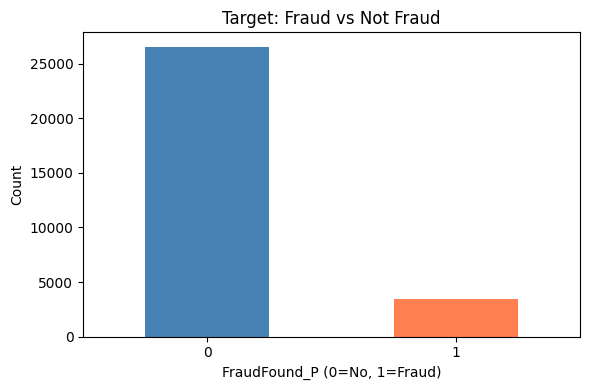

In [24]:
df['FraudFound_P'] = (df['fraud_reported'] == 'Y').astype(int)
print('Class distribution (FraudFound_P):')
print(df['FraudFound_P'].value_counts())
print('\nClass ratio (imbalance):')
print(df['FraudFound_P'].value_counts(normalize=True))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
df['FraudFound_P'].value_counts().plot(kind='bar', color=['steelblue','coral'])
plt.title('Target: Fraud vs Not Fraud')
plt.xlabel('FraudFound_P (0=No, 1=Fraud)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns:', cat_cols)
for c in cat_cols:
    print(f'{c}: {df[c].nunique()} unique')

Categorical columns: ['policy_id', 'policy_state', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'police_report_available', 'fraud_reported']
policy_id: 30000 unique
policy_state: 10 unique
insured_sex: 3 unique
insured_education_level: 4 unique
insured_occupation: 8 unique
insured_hobbies: 7 unique
incident_date: 731 unique
incident_type: 4 unique
collision_type: 4 unique
incident_severity: 3 unique
authorities_contacted: 3 unique
incident_state: 10 unique
incident_city: 17931 unique
police_report_available: 2 unique
fraud_reported: 2 unique


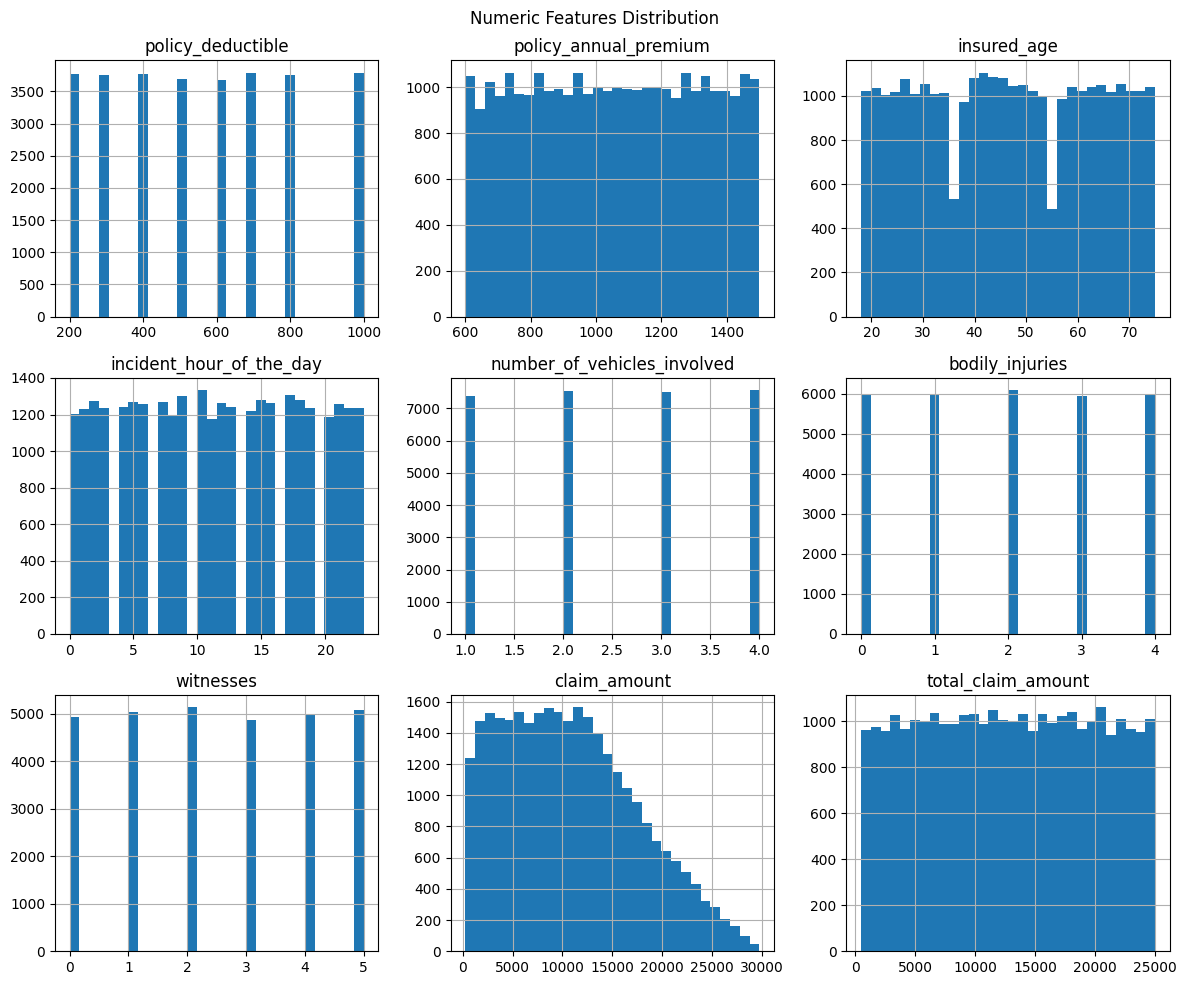

In [26]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'FraudFound_P']
df[num_cols].hist(bins=30, figsize=(12,10), layout=(3,3))
plt.suptitle('Numeric Features Distribution')
plt.tight_layout()
plt.show()

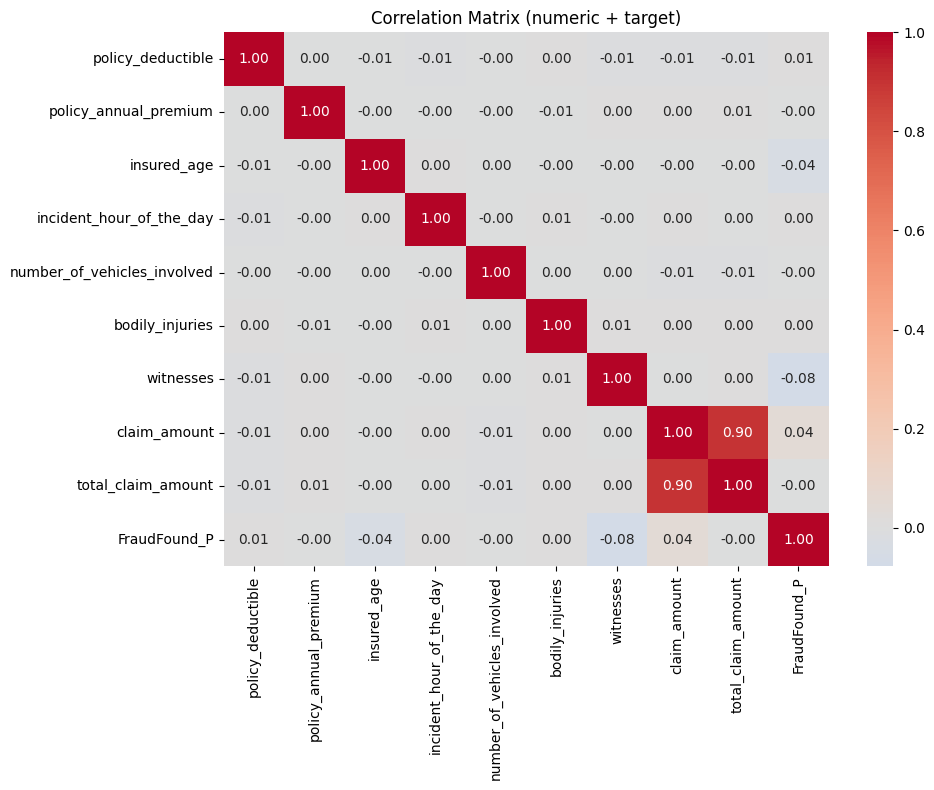

In [27]:
corr = df[num_cols + ['FraudFound_P']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (numeric + target)')
plt.tight_layout()
plt.show()

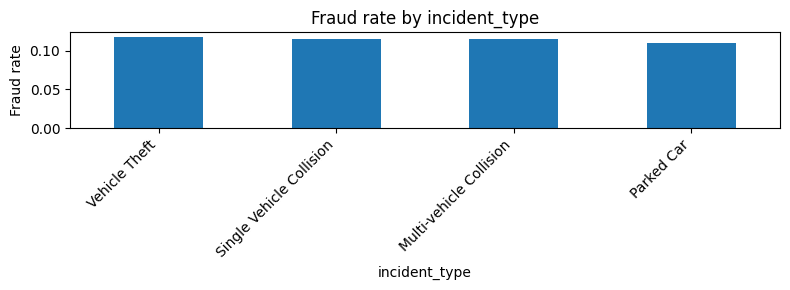

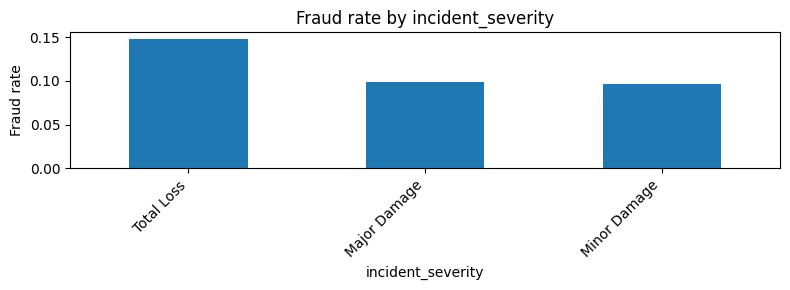

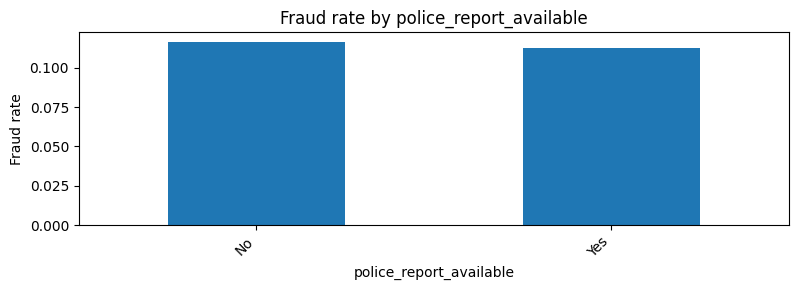

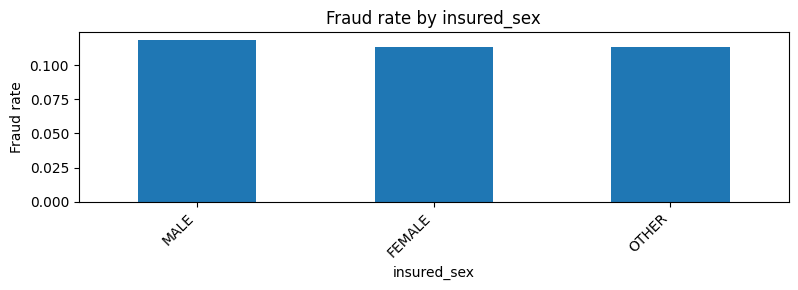

In [28]:
for col in ['incident_type', 'incident_severity', 'police_report_available', 'insured_sex']:
    if col in df.columns:
        rate = df.groupby(col)['FraudFound_P'].mean()
        rate.sort_values(ascending=False).plot(kind='bar', figsize=(8,3), title=f'Fraud rate by {col}')
        plt.xticks(rotation=45, ha='right')
        plt.ylabel('Fraud rate')
        plt.tight_layout()
        plt.show()

---
## 3. Data Preprocessing

In [29]:
y = df['FraudFound_P'].copy()
assert set(y.unique()).issubset({0, 1}), 'Target must be binary 0/1'
drop_cols = ['policy_id', 'fraud_reported', 'FraudFound_P']
X_raw = df.drop(columns=[c for c in drop_cols if c in df.columns])
print('Missing before:', X_raw.isnull().sum().sum())
X_raw = X_raw.fillna(X_raw.mode().iloc[0])
numeric_cols = X_raw.select_dtypes(include=[np.number]).columns
X_raw[numeric_cols] = X_raw[numeric_cols].fillna(X_raw[numeric_cols].median())
print('Missing after:', X_raw.isnull().sum().sum())

X_raw.head()

Missing before: 7564
Missing after: 0


,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,incident_type,...,authorities_contacted,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount
0,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,Parked Car,...,Fire,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60
1,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,Vehicle Theft,...,Fire,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81
2,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,Parked Car,...,Police,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59
3,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,Parked Car,...,Police,NC,Josephchester,22,3,3,5,No,13188.92,14204.34
4,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,Single Vehicle Collision,...,Fire,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84


---
## 4. Feature Engineering

In [31]:
X = X_raw.copy()
if 'incident_date' in X.columns:
    X['incident_date'] = pd.to_datetime(X['incident_date'], errors='coerce')
    X['incident_year'] = X['incident_date'].dt.year
    X['incident_month'] = X['incident_date'].dt.month
    X['incident_day_of_week'] = X['incident_date'].dt.dayofweek
    X = X.drop(columns=['incident_date'])
if 'claim_amount' in X.columns and 'total_claim_amount' in X.columns:
    X['claim_ratio'] = X['claim_amount'] / (X['total_claim_amount'].replace(0, np.nan))
    X['claim_ratio'] = X['claim_ratio'].fillna(1)
if 'policy_annual_premium' in X.columns and 'policy_deductible' in X.columns:
    X['premium_per_deductible'] = X['policy_annual_premium'] / (X['policy_deductible'].replace(0, np.nan))
    X['premium_per_deductible'] = X['premium_per_deductible'].fillna(X['policy_annual_premium'])
if 'police_report_available' in X.columns:
    X['police_report_available'] = (X['police_report_available'].str.upper() == 'YES').astype(int)
if 'incident_severity' in X.columns:
    X['is_total_loss'] = (X['incident_severity'].str.contains('Total', case=False, na=False)).astype(int)

print('Engineered features added. New shape:', X.shape)
X.head()

Engineered features added. New shape: (30000, 27)


,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_type,collision_type,...,witnesses,police_report_available,claim_amount,total_claim_amount,incident_year,incident_month,incident_day_of_week,claim_ratio,premium_per_deductible,is_total_loss
0,GA,400,1430.78,74,OTHER,High School,Manager,reading,Parked Car,Front,...,0,1,8161.36,11677.60,2024,6,3,0.698890,3.576950,1
1,PA,300,854.49,74,MALE,College,Lawyer,chess,Vehicle Theft,Rear,...,5,0,18561.79,18027.81,2025,3,6,1.029620,2.848300,1
2,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,Parked Car,Unknown,...,1,0,10734.61,10375.59,2025,1,6,1.034602,3.118200,1
3,CA,600,622.42,37,MALE,PhD,Teacher,yachting,Parked Car,Rear,...,5,0,13188.92,14204.34,2024,6,0,0.928513,1.037367,1
4,MI,700,1458.17,31,OTHER,PhD,Sales,reading,Single Vehicle Collision,Side,...,4,0,21864.69,24038.84,2024,5,1,0.909557,2.083100,0


In [32]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
for c in ['incident_city']:
    if c in cat_cols:
        cat_cols.remove(c)
        X = X.drop(columns=[c], errors='ignore')

preprocessor = ColumnTransformer(
    [
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ],
    remainder='drop'
)

X_processed = preprocessor.fit_transform(X)
feature_names = (num_cols + 
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)))
print('Processed feature matrix shape:', X_processed.shape)
print('Feature names count:', len(feature_names))

Processed feature matrix shape: (30000, 62)
Feature names count: 62


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.25, random_state=42, stratify=y
)
print('Train size:', X_train.shape[0], 'Test size:', X_test.shape[0])

Train size: 22500 Test size: 7500


---
## 5. Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42, k_neighbors=3, sampling_strategy=0.35)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print('Applied SMOTE. Train size:', X_train.shape[0])
except ImportError:
    pass

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced'),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=14, min_samples_leaf=3, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=6, learning_rate=0.08, min_samples_leaf=3, random_state=42)
}
try:
    from xgboost import XGBClassifier
    models['XGBoost'] = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.08, random_state=42, eval_metric='logloss')
except ImportError:
    pass

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    results.append({'Model': name, 'CV F1 Mean': scores.mean(), 'CV F1 Std': scores.std()})
    print(f'{name}: F1 = {scores.mean():.4f} (+/- {scores.std():.4f})')

cv_df = pd.DataFrame(results)
cv_df.sort_values('CV F1 Mean', ascending=False)

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

eval_results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    trained_models[name] = model
    
    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]) if hasattr(model, 'predict_proba') else 0
    acc = accuracy_score(y_test, y_pred)
    eval_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': report['weighted avg']['f1-score'],
        'ROC-AUC': auc
    })

eval_df = pd.DataFrame(eval_results)
eval_df = eval_df.sort_values('Accuracy', ascending=False)
eval_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
6,Gradient Boosting,0.880533,0.830422,0.880533,0.840400,0.728637
2,K-Nearest Neighbors,0.876267,0.806711,0.876267,0.831739,0.568511
1,Naive Bayes,0.867333,0.820032,0.867333,0.837267,0.638986
5,Random Forest,0.846000,0.838565,0.846000,0.842134,0.730992
4,Decision Tree,0.820533,0.818147,0.820533,0.819331,0.551464
3,SVM,0.745867,0.847331,0.745867,0.783891,0.696413
0,Logistic Regression,0.626667,0.845519,0.626667,0.694357,0.670308


In [36]:
best_name = eval_df.iloc[0]['Model']
best_model = trained_models[best_name]
y_pred_best = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_best)
print('Best model:', best_name)
print('Accuracy (test set):', round(accuracy, 4), f'({accuracy:.2%})')
print('\nClassification Report (test set):')
print(classification_report(y_test, y_pred_best))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_best))

Best model: Gradient Boosting
Accuracy (test set): 0.8805 (88.05%)

Classification Report (test set):
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      6640
           1       0.37      0.06      0.10       860

    accuracy                           0.88      7500
   macro avg       0.63      0.52      0.52      7500
weighted avg       0.83      0.88      0.84      7500

Confusion Matrix:
[[6553   87]
 [ 809   51]]


---
## 6. Save Best Model and Preprocessor

In [37]:
import pickle
import os

os.makedirs('../saved_models', exist_ok=True)
with open('../saved_models/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)
with open('../saved_models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('../saved_models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)
with open('../saved_models/input_columns.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print('Saved: preprocessor.pkl, best_model.pkl, feature_names.pkl, input_columns.pkl')

Saved: preprocessor.pkl, best_model.pkl, feature_names.pkl, input_columns.pkl


In [38]:
pd.DataFrame(X_processed, columns=feature_names).to_csv('../dataset/processed_features.csv', index=False)
y.to_csv('../dataset/target.csv', index=False)
print('Processed data saved.')

Processed data saved.
